# **M2-INASYS / OPTIMSYS Courses 1/2: Assignment**

## **Topic**


#### **Background**

One of the most frequently encountered kinds of information in the healthcare is natural language data.

Every interaction between a patient and a healthcare provider, from clinical notes and medical reports to conversations and diagnostic summaries generates textual data.

Understanding and leveraging data modelling methods tailored to model this kind of health data has therefore become essential for improving care quality, decision support, and knowledge discovery.

#### **Aims**

The aim of this lab is to help you understand how to process text data in the healthcare domain, especially when dealing with unstructured data where the explanatory variable is text and the variable of interest is categorical.

## **Section 1**

#### **What is clinical text Classification?**

To better understand the concept of clinical text classification, take a look at the following figure.

The idea is similar to reading a text and, based on its content,  classified it in the appropriate category box.
In this example, the three boxes represent the number of possible classes in your classification problem.

![image.png](https://content.abbyy.com/-/media/project/abbyy/abbyy/products/ai-document-processing/document-classification-and-splitting/document-classification-and-splitting-step-2.png?h=418&iar=0&w=743)

#### **Does the computer understand text data in its raw format?**


![image.png](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSf8bk7th5n_3WR-FSysv0nWLzPcR8kPEftDg&s)


The answer is clearly No!

Computers cannot directly understand text as humans do. They process numbers, not words.

Therefore, before a model can learn the relationship between the input text and the output, we must transform the text into a numerical representation that the computer can interpret.

#### **Which methods allow us to represent words as numerical vectors ?**


There exist two kinds of embedding methods: traditional approaches and neural approaches (e.g., static word embeddings and contextualized word embeddings).


![image.png](https://ghimirearun.com.np/img/posts/embedding-classification.jpg)


Since we have not yet studied **deep learning methods**, we will focus on traditional techniques such as Bag of Words, TF-IDF, and co-occurrence matrix methods.

#### **Bag of Words**

A Bag-of-Words (BoW) is a text representation method that describes the frequency of words within a document.

To build a BoW representation, we need two main components:

  - A vocabulary of known words.

  - A measure indicating the occurency of these words.


  E.g.

  Data :

    - P1 : The doctor received the patients

    - P2  : The nurse helped the patients

    - P3  :  The doctor and the nurse talked

  Vocabulary:

    - {the, doctor, received, patients, nurse, helped, and, talked}


  Frequency of each term:

P1 : The doctor received the patients
    The ---> 2

    doctor ---> 1

    received ---> 1

    patients ---> 1

P2  : The nurse helped the patients

    The ---> 2

    nurse ---> 1

    helped ---> 1

    patients ---> 1

    ... etc

  Bag-of-Words (BoW) representation

    The set of unique word become the explanatory variables

            the, doctor, received, patients, nurse, helped, and, talked
        
        P1   2 ,  1    ,    1    ,     1   ,   0   , 0   ,  0  ,   0

        P2   2 ,  0    ,    0    ,     1   ,   1   ,  1  ,  0  ,   0

        P3   ....






The dataset below is provided to help you test and validate the functions you will implement.

In [7]:
import pandas as pd

In [8]:
data = pd.DataFrame(data=[["i didnt feel humiliated",
0],["i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and ...",
0],["im grabbing a minute to post i feel greedy wrong",3],["i am ever feeling nostalgic about the fireplace i will know that it is still on the property",
2],["i am feeling grouchy",
3],["ive been feeling a little burdened lately wasnt sure why that was",
0],["ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i a...",
5],["i feel as confused about life as a teenager or as jaded as a year old man",
4]], columns=["text", "label"])

In [6]:
data.shape

(8, 2)

Q1: Removing stop Words

The data contains many stop words (e.g., like, the, is, are, etc.) that do not provide relevant information to the model.
Write a function to remove these stop words from a text.

Example of Code

```
! pip install spacy

import spacy

nlp = spacy.load("en_core_web_sm")

doc = nlp("The researchers are developing advanced algorithms.")

Filter stopwords using spaCy

filtered_words = [token.text for token in doc if not token.is_stop]

```

Input sentence:

  - The researchers are developing advanced algorithms.

Expected output:


  - ['researchers', 'developing', 'advanced', 'algorithms', '.']


Answer: The function remove_stop_words uses spaCy's English pipeline: the text is tokenized, then every token flagged as a stop word (token.is_stop: "the", "are", "is"...) is dropped. It returns the list of remaining tokens, e.g. ['researchers', 'developing', 'advanced', 'algorithms', '.'] for the example sentence.




In [9]:
import spacy
nlp = spacy.load("en_core_web_sm")

def remove_stop_words(text):
    doc = nlp(text)
    return [token.text for token in doc if not token.is_stop]

print(remove_stop_words("The researchers are developing advanced algorithms."))

['researchers', 'developing', 'advanced', 'algorithms', '.']


Q2 : Use the function you defined in Q1 to remove stop words from the provided dataset (data).

In [10]:
data["tokens"] = data["text"].apply(lambda t: [w for w in remove_stop_words(t) if w.isalpha()])
data["text_clean"] = data["tokens"].apply(lambda t: " ".join(t))
data[["text", "tokens", "text_clean"]]

,text,tokens,text_clean
0,i didnt feel humiliated,"[nt, feel, humiliated]",nt feel humiliated
1,i can go from feeling so hopeless to so damned...,"[feeling, hopeless, damned, hopeful, cares]",feeling hopeless damned hopeful cares
2,im grabbing a minute to post i feel greedy wrong,"[m, grabbing, minute, post, feel, greedy, wrong]",m grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,"[feeling, nostalgic, fireplace, know, property]",feeling nostalgic fireplace know property
4,i am feeling grouchy,"[feeling, grouchy]",feeling grouchy
5,ive been feeling a little burdened lately wasn...,"[ve, feeling, little, burdened, lately, nt, sure]",ve feeling little burdened lately nt sure
6,ive been taking or milligrams or times recomme...,"[ve, taking, milligrams, times, recommended, v...",ve taking milligrams times recommended ve fall...
7,i feel as confused about life as a teenager or...,"[feel, confused, life, teenager, jaded, year, ...",feel confused life teenager jaded year old man


Answer: The function was applied to each sentence of the dataset. Two columns were added: "tokens" (list of the remaining words) and "text_clean" (the same words joined in a string, needed later by scikit-learn). Stop words (e.g. "i", "am", "a", "that") and punctuation were removed, so each sentence keeps only its informative words (e.g. "feeling", "grouchy"). 

Q3: Write a function that counts the occurrences of each word in a given sentence.

Use a dictionary to store the results, where:

  - keys represent the words, and

  - values represent the number of times each word appears.

In [14]:
def count_words(sentence):
    if isinstance(sentence, str):
        sentence = sentence.split()
    counts = {}
    for word in sentence:
        counts[word] = counts.get(word, 0) + 1
    return counts

print(count_words("the doctor received the patients"))

{'the': 2, 'doctor': 1, 'received': 1, 'patients': 1}


The function lopps over the words of a sentence and stores in a dictionary the number of occurrences of each word (key = word, value = count). A word not yet in the dictionary starts at 0 with counts.get(word, 0) and is incremented by 1. example : "the doctor received the patients" gives {'the': 2, 'doctor':1, 'received':1, 'patients :1'}. 

Q4: Use the function defined above to represent each element (sentence) in the dataset as a numerical vector (Look at the definition of BOW).

In [15]:
vocabulary = sorted(set(w for tokens in data["tokens"] for w in tokens))

def to_vector(tokens):
    counts = count_words(tokens)
    return [counts.get(w, 0) for w in vocabulary]

bow_manual = pd.DataFrame([to_vector(t) for t in data["tokens"]], columns=vocabulary)
bow_manual

,asleep,burdened,cares,confused,damned,fallen,faster,feel,feeling,fireplace,...,post,property,recommended,sure,taking,teenager,times,ve,wrong,year
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,0,1,1,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
5,0,1,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,1,0,0
6,1,0,0,0,0,1,1,0,0,0,...,0,0,1,0,1,0,1,2,0,0
7,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,1


The vocabulary is the sorted set of all unique words of the cleaned corpus. Each sentence becomes a vector whose size is the vocabulary size: the value at position j is the number of times word j occurs in the sentence (0 if absent), obtained with count_words. The result is a matrix of 8 documents × V words, where each word is an explanatory variable (see the BoW definition). It is very sparse (mostly zeros).

Q5: Use CountVectorizer from scikit-learn to convert the dataset (data) into its Bag-of-Words numerical representation.

In [18]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(token_pattern=r"(?u)\b\w+\b")
X_bow = cv.fit_transform(data["text_clean"])
bow_sklearn = pd.DataFrame(X_bow.toarray(), columns=cv.get_feature_names_out())
display(bow_sklearn)
print("Same shape:", bow_sklearn.shape == bow_manual.shape)
print("Same as manual BoW:", (bow_sklearn.values == bow_manual.values).all())

,asleep,burdened,cares,confused,damned,fallen,faster,feel,feeling,fireplace,...,post,property,recommended,sure,taking,teenager,times,ve,wrong,year
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,0,1,1,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
5,0,1,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,1,0,0
6,1,0,0,0,0,1,1,0,0,0,...,0,0,1,0,1,0,1,2,0,0
7,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,1


Same shape: True
Same as manual BoW: True


CountVectorizer builds the vocabulary and the word-count matrix in two lines (fit_transform on the cleaned texts). It returns a sparse matrix (documents × vocabulary) that we converted to a DataFrame for display. By default it ignores one-letter words, which created a difference of one column with our manual Bag-of-Words (38 vs 39 words); setting token_pattern=r"(?u)\b\w+\b" keeps them, and the result is then identical to the manual BoW of Q4, which validates our implementation.

#### **TF-IDF : Term Frequency–Inverse Document Frequency**


TF-IDF multiplies TF by IDF to calculate the weight of a word in a document.
It measures how important a word is to a document relative to a larger collection of documents. For better understanding --> (https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/)

### Step 1: Calculate Term Frequency (TF)

The Term Frequency (TF) measures how frequently a term appears in a document.

**Formula:**

TF(word, Document) = Number of times the word appears in the document / Total number of words in the document

E.g selected word : doctor

  - D1 : The doctor received the patients

  - D2  : The nurse helped the patients

  - D3  :  The doctor and the nurse talked


Vocabulary

  - {the, doctor, received, patients, nurse, helped, and, talked}

For document D1

  TF(doctor, D1) = 1/8

For document D2

  TF(doctor, D2) = 0

etc.


### Step 2: Calculate Inverse Document Frequency (IDF)

The IDF reduces the weight of common words that appear in many documents and increases the weight of rare words.

**Formula:**

IDF(word) = log(Total number of documents in corpus / Number of documents containing the word)

E.g Selected word: doctor

IDF(doctor) = log(3 / 2)


### Step 3: Calculate TF-IDF

The TF-IDF value for each word in each document is obtained by multiplying its TF by its IDF.

**Formula:**

TF-IDF(word, Document) = TF(word, Document) × IDF(word)

E.g Selected word : doctor

TF-IDF(doctor, D1) = (1 / 8) × log(3 / 2)

TF-IDF(doctor, D2) = 0 × log(3 / 2) = 0

TF-IDF(doctor, D3) = (1 / 8) × log(3 / 2)


Q6 : Calculate the TF-IDF score for each word in the vocabulary and for each document in the corpus. Find the numerical representation of the dataset (data).

In [19]:
data["tokens"] = data["text"].apply(lambda t: [w for w in remove_stop_words(t) if w.isalpha()])
data["text_clean"] = data["tokens"].apply(lambda t: " ".join(t))
data[["text", "tokens", "text_clean"]]

,text,tokens,text_clean
0,i didnt feel humiliated,"[nt, feel, humiliated]",nt feel humiliated
1,i can go from feeling so hopeless to so damned...,"[feeling, hopeless, damned, hopeful, cares]",feeling hopeless damned hopeful cares
2,im grabbing a minute to post i feel greedy wrong,"[m, grabbing, minute, post, feel, greedy, wrong]",m grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,"[feeling, nostalgic, fireplace, know, property]",feeling nostalgic fireplace know property
4,i am feeling grouchy,"[feeling, grouchy]",feeling grouchy
5,ive been feeling a little burdened lately wasn...,"[ve, feeling, little, burdened, lately, nt, sure]",ve feeling little burdened lately nt sure
6,ive been taking or milligrams or times recomme...,"[ve, taking, milligrams, times, recommended, v...",ve taking milligrams times recommended ve fall...
7,i feel as confused about life as a teenager or...,"[feel, confused, life, teenager, jaded, year, ...",feel confused life teenager jaded year old man


The function was applied to each sentence of the dataset. Two columns were added: "tokens" (list of the remaining words) and "text_clean" (the same words joined in a string, needed later by scikit-learn). Stop words (e.g. "i", "am", "a", "that") and punctuation were removed, so each sentence keeps only its informative words (e.g. "feeling", "grouchy").

Q7 : Use the TfidfTransformer from scikit-learn to compute the Tf-IDF representation of the dataset (data).

In [20]:
from sklearn.feature_extraction.text import TfidfTransformer

tt = TfidfTransformer()
X_tfidf = tt.fit_transform(X_bow)
tfidf_sklearn = pd.DataFrame(X_tfidf.toarray(), columns=cv.get_feature_names_out())
tfidf_sklearn.round(3)

,asleep,burdened,cares,confused,damned,fallen,faster,feel,feeling,fireplace,...,post,property,recommended,sure,taking,teenager,times,ve,wrong,year
0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.485,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.000,0.000,0.477,0.000,0.477,0.000,0.000,0.000,0.302,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.283,0.000,0.000,...,0.392,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.392,0.000
3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.302,0.477,...,0.000,0.477,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.536,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5,0.000,0.415,0.000,0.000,0.000,0.000,0.000,0.000,0.263,0.000,...,0.000,0.000,0.000,0.415,0.000,0.000,0.000,0.348,0.000,0.000
6,0.304,0.000,0.000,0.000,0.000,0.304,0.304,0.000,0.000,0.000,...,0.000,0.000,0.304,0.000,0.304,0.000,0.304,0.510,0.000,0.000
7,0.000,0.000,0.000,0.365,0.000,0.000,0.000,0.264,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.365,0.000,0.000,0.000,0.365


Answer ...

## **Section 2**

In this section, we will compare the two methods and see which one represents the data more accurately in a multidimensional space.

A good representation allows the trained model to generalize well to unseen data.

![image.png](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS8IHR-E4DwSI2hMm6EIJJTZ4NAAVxQ1aUOMg&s)

Q8: Use the Decision Tree algorithm to compare both representations (TF-IDF, BOW).

--------------------------------------------------------------------------------

**Dataset 1**

The dataset is a curated collection of mental health statuses tagged from various statements.

The dataset is provided at the following link: https://github.com/EDJINEDJA/Health-Data-modelling/tree/main/lab2/data1

--------------------------------------------------------------------------------

NB: Before starting the modeling stage, please perform an exploratory analysis using appropriate statistical tools.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df1 = pd.read_csv("data1/Combined Data.csv")
print(df1.shape)
print(df1.columns.tolist())
display(df1.head())
df1.info()

(53043, 3)
['Unnamed: 0', 'statement', 'status']


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


<class 'pandas.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  53043 non-null  int64
 1   statement   52681 non-null  str  
 2   status      53043 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.2 MB


Missing values:
 statement    362
status         0
dtype: int64
Duplicated statements: 1969
Shape after cleaning: (51073, 3)
                      count     %
status                           
Normal                16039  31.4
Depression            15087  29.5
Suicidal              10641  20.8
Anxiety                3617   7.1
Bipolar                2501   4.9
Stress                 2293   4.5
Personality disorder    895   1.8


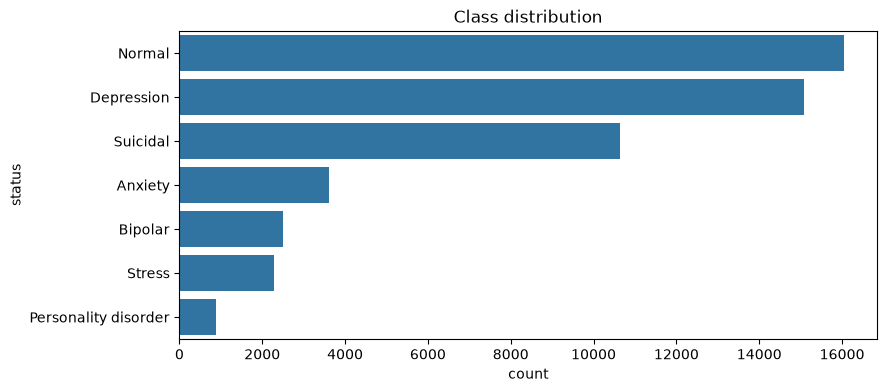

In [22]:
text_col, label_col = "statement", "status"

print("Missing values:\n", df1[[text_col, label_col]].isna().sum())
print("Duplicated statements:", df1.duplicated(subset=[text_col]).sum())

df1 = df1.dropna(subset=[text_col, label_col]).drop_duplicates(subset=[text_col]).reset_index(drop=True)
print("Shape after cleaning:", df1.shape)

counts = df1[label_col].value_counts()
print(pd.concat([counts, (counts / len(df1) * 100).round(1)], axis=1, keys=["count", "%"]))

plt.figure(figsize=(9, 4))
sns.countplot(data=df1, y=label_col, order=counts.index)
plt.title("Class distribution")
plt.show()

count    51073.0
mean       112.7
std        164.1
min          1.0
25%         15.0
50%         61.0
75%        147.0
max       6300.0
Name: n_words, dtype: float64
                       mean  median   max
status                                   
Anxiety               143.1   102.0  1592
Bipolar               178.3   130.0  4804
Depression            168.2   113.0  4239
Normal                 17.4    10.0   255
Personality disorder  177.9   133.0  5419
Stress                111.7    86.0  1606
Suicidal              146.5    92.0  6300


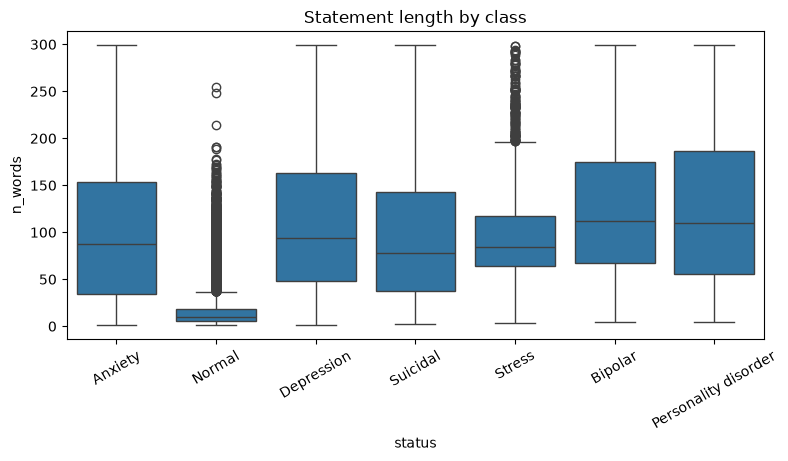

In [23]:
df1["n_words"] = df1[text_col].astype(str).str.split().str.len()
print(df1["n_words"].describe().round(1))
print(df1.groupby(label_col)["n_words"].agg(["mean", "median", "max"]).round(1))

plt.figure(figsize=(9, 4))
sns.boxplot(data=df1[df1["n_words"] < 300], x=label_col, y="n_words")
plt.xticks(rotation=30)
plt.title("Statement length by class")
plt.show()

In [24]:
import time, spacy
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

nlp = spacy.load("en_core_web_sm")
stop_list = list(nlp.Defaults.stop_words)

X_text_train, X_text_test, y_train, y_test = train_test_split(
    df1[text_col], df1[label_col], test_size=0.2, random_state=42, stratify=df1[label_col]
)

cv1 = CountVectorizer(stop_words=stop_list, max_features=5000)
Xtr_bow = cv1.fit_transform(X_text_train)      # le vocabulaire est appris sur le train uniquement
Xte_bow = cv1.transform(X_text_test)

tt1 = TfidfTransformer()
Xtr_tfidf = tt1.fit_transform(Xtr_bow)
Xte_tfidf = tt1.transform(Xte_bow)

print(Xtr_bow.shape, Xte_bow.shape)

/home/gloriabad2020/env/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ll', 've'] not in stop_words.
  warnings.warn(


(40858, 5000) (10215, 5000)


In [25]:
results = {}
for name, (Xtr, Xte) in {"BoW": (Xtr_bow, Xte_bow), "TF-IDF": (Xtr_tfidf, Xte_tfidf)}.items():
    start = time.time()
    model = DecisionTreeClassifier(random_state=42).fit(Xtr, y_train)
    train_time = time.time() - start
    pred = model.predict(Xte)
    results[name] = {
        "train_accuracy": round(model.score(Xtr, y_train), 3),
        "test_accuracy": round(accuracy_score(y_test, pred), 3),
        "macro_F1": round(f1_score(y_test, pred, average="macro"), 3),
        "train_time_s": round(train_time, 1),
        "depth": model.get_depth(),
    }
    print(name)
    print(classification_report(y_test, pred))

pd.DataFrame(results).T

BoW
                      precision    recall  f1-score   support

             Anxiety       0.60      0.60      0.60       723
             Bipolar       0.61      0.47      0.53       500
          Depression       0.61      0.59      0.60      3018
              Normal       0.81      0.88      0.84      3208
Personality disorder       0.44      0.28      0.34       179
              Stress       0.32      0.29      0.30       459
            Suicidal       0.54      0.55      0.54      2128

            accuracy                           0.65     10215
           macro avg       0.56      0.52      0.54     10215
        weighted avg       0.64      0.65      0.64     10215

TF-IDF
                      precision    recall  f1-score   support

             Anxiety       0.59      0.56      0.58       723
             Bipolar       0.53      0.46      0.49       500
          Depression       0.58      0.58      0.58      3018
              Normal       0.82      0.87      0.84    

,train_accuracy,test_accuracy,macro_F1,train_time_s,depth
BoW,0.998,0.649,0.538,26.7,1338.0
TF-IDF,0.998,0.639,0.529,27.4,1362.0


After cleaning, the dataset contains 51,073 statements across 7 imbalanced mental-health classes. Texts average 113 words, with a few very long statements. An 80/20 stratified split and macro F1 were used to account for class imbalance.
BoW and TF-IDF were compared using the same Decision Tree and a vocabulary of 5,000 terms learned only from the training set. BoW performed slightly better, achieving 64.9% test accuracy and a macro F1 of 0.538, compared with 63.9% and 0.529 for TF-IDF. Training times were similar.
Both models reached 99.8% training accuracy, indicating strong overfitting. Minority classes were generally harder to classify. BoW is selected for Section 3, although its advantage is small. Tree regularization or ensemble methods could improve generalization.

## **Section 3**

Q9: In this section, you will use the best representation method selected between TF-IDF and Bag-of-Words (BoW) to test the robustness and performance of four classifiers:

  - Decision Tree

  - Bagging algorithms

  - Boosting algorithms

  - Stacking algorithms


--------------------------------------------------------------------------------

**Dataset 2**

The dataset consists of clinical summaries describing five different classes of patient conditions.

The dataset is provided at the following link: https://github.com/EDJINEDJA/Health-Data-modelling/tree/main/lab2/data2/Medical-Abstracts-TC-Corpus-main

--------------------------------------------------------------------------------



In [35]:
import pandas as pd, time, spacy
from sklearn.feature_extraction.text import CountVectorizer

train = pd.read_csv("data2/medical_tc_train.csv")
test = pd.read_csv("data2/medical_tc_test.csv")
label_col = [c for c in train.columns if train[c].nunique() <= 10][0]
text_col = max([c for c in train.columns if c != label_col],
               key=lambda c: train[c].ast
                   ype(str).str.len().mean())
print("colonnes:", train.columns.tolist(), "| classe:", label_col, "| texte:", text_col)
print(train.shape, test.shape)

nlp = spacy.load("en_core_web_sm")
cv2 = CountVectorizer(stop_words=list(nlp.Defaults.stop_words), max_features=3000)
Xtr = cv2.fit_transform(train[text_col])
Xte = cv2.transform(test[text_col])
ytr, yte = train[label_col], test[label_col]
print("BoW:", Xtr.shape, Xte.shape)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2497863030.py, line 8)

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier, StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Bagging": BaggingClassifier(DecisionTreeClassifier(), n_estimators=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
    "Stacking": StackingClassifier(
        estimators=[("dt", DecisionTreeClassifier(random_state=42)),
                    ("rf", RandomForestClassifier(n_estimators=50, random_state=42)),
                    ("lr", LogisticRegression(max_iter=1000))],
        final_estimator=LogisticRegression(max_iter=1000), cv=3),
}

rows = []
for name, model in models.items():
    start = time.time(); model.fit(Xtr, ytr); train_time = time.time() - start
    pred = model.predict(Xte)
    rows.append({"model": name,
                 "train_accuracy": round(model.score(Xtr, ytr), 3),
                 "test_accuracy": round(accuracy_score(yte, pred), 3),
                 "macro_F1": round(f1_score(yte, pred, average="macro"), 3),
                 "train_time_s": round(train_time, 1)})
    print("OK:", name, flush=True)

results2 = pd.DataFrame(rows).set_index("model")
results2

OK: Decision Tree
OK: Bagging
OK: Random Forest
OK: AdaBoost
OK: Gradient Boosting
OK: Stacking


,train_accuracy,test_accuracy,macro_F1,train_time_s
model,,,,
Decision Tree,0.818,0.420,0.416,5.8
Bagging,0.809,0.465,0.463,58.1
Random Forest,0.818,0.474,0.464,147.6
AdaBoost,0.498,0.491,0.356,7.2
Gradient Boosting,0.659,0.550,0.528,30.5
Stacking,0.725,0.510,0.474,299.5


In [33]:
lines = "\n".join(f"- {m}: test accuracy {r.test_accuracy}, macro F1 {r.macro_F1}" for m, r in results2.iterrows())
print(f"""Answer: Dataset 2 contains {len(train)} training and {len(test)} test clinical abstracts, split in {ytr.nunique()} condition classes. The best representation of Section 2 
(Bag-of-Words) was used: stop words removed, vocabulary limited to the 3000
most frequent words and learned on the training set only. Four families of 
classifiers were tested: a single Decision Tree; Bagging algorithms 
(Bagging and Random Forest: many trees trained independently on bootstrap samples, 
predictions combined by vote); Boosting algorithms (AdaBoost and Gradient Boosting: weak
learners added one after another, each correcting the errors of the previous ones); and Stacking (a Logistic Regression meta-model 
combining a Decision Tree, a Random Forest and a Logistic Regression).
Results on the test set:
{lines}""")

Answer: Dataset 2 contains 11550 training and 2888 test clinical abstracts, split in 5 condition classes. The best representation of Section 2 (Bag-of-Words) was used: stop words removed, vocabulary limited to the 3000 most frequent words and learned on the training set only. Four families of classifiers were tested: a single Decision Tree; Bagging algorithms (Bagging and Random Forest: many trees trained independently on bootstrap samples, predictions combined by vote); Boosting algorithms (AdaBoost and Gradient Boosting: weak learners added one after another, each correcting the errors of the previous ones); and Stacking (a Logistic Regression meta-model combining a Decision Tree, a Random Forest and a Logistic Regression). Results on the test set:
- Decision Tree: test accuracy 0.42, macro F1 0.416
- Bagging: test accuracy 0.465, macro F1 0.463
- Random Forest: test accuracy 0.474, macro F1 0.464
- AdaBoost: test accuracy 0.491, macro F1 0.356
- Gradient Boosting: test accuracy 0.55

Answer: Dataset 2 contains 11550 training and 2888 test clinical abstracts, split in 5 condition classes. The best representation of Section 2 (Bag-of-Words) was used: stop words removed, vocabulary limited to the 3000 most frequent words and learned on the training set only. Four families of classifiers were tested: a single Decision Tree; Bagging algorithms (Bagging and Random Forest: many trees trained independently on bootstrap samples, predictions combined by vote); Boosting algorithms (AdaBoost and Gradient Boosting: weak learners added one after another, each correcting the errors of the previous ones); and Stacking (a Logistic Regression meta-model combining a Decision Tree, a Random Forest and a Logistic Regression).

Results on the test set:

| Model | Test accuracy | Macro F1 |
|---|---|---|
| Decision Tree | 0.420 | 0.416 |
| Bagging | 0.465 | 0.463 |
| Random Forest | 0.474 | 0.464 |
| AdaBoost | 0.491 | 0.356 |
| Gradient Boosting | 0.550 | 0.528 |
| Stacking | 0.510 | 0.474 |

Q10: How long does it take to train each model?

In [36]:
lines = "\n".join(f"- {m}: {r.train_time_s} seconds" for m, r in results2.iterrows())
fastest = results2["train_time_s"].idxmin()
slowest = results2["train_time_s"].idxmax()
tmin, tmax = results2["train_time_s"].min(), results2["train_time_s"].max()
print(f"""Answer: Training times on the training set ({len(train)} abstracts, 3000 features):
{lines}
The fastest model is the {fastest} ({tmin} s) and the slowest is the {slowest} ({tmax} s), about {tmax / max(tmin, 0.1):.0f} times longer. These differences come from how each family works: a Decision Tree is a single model; Bagging and Random Forest train many trees independently (so the cost is roughly the number of trees times that of one tree, and the work can be parallelized); AdaBoost and Gradient Boosting add learners one after another, so training is sequential and cannot be parallelized; Stacking is expensive because every base model is trained several times (3-fold cross-validation) and then a final model is trained on their predictions.""")

Answer: Training times on the training set (11550 abstracts, 3000 features):
- Decision Tree: 5.8 seconds
- Bagging: 58.1 seconds
- Random Forest: 147.6 seconds
- AdaBoost: 7.2 seconds
- Gradient Boosting: 30.5 seconds
- Stacking: 299.5 seconds
The fastest model is the Decision Tree (5.8 s) and the slowest is the Stacking (299.5 s), about 52 times longer. These differences come from how each family works: a Decision Tree is a single model; Bagging and Random Forest train many trees independently (so the cost is roughly the number of trees times that of one tree, and the work can be parallelized); AdaBoost and Gradient Boosting add learners one after another, so training is sequential and cannot be parallelized; Stacking is expensive because every base model is trained several times (3-fold cross-validation) and then a final model is trained on their predictions.


Training times on the training set (11550 abstracts, 3000 features):
- Decision Tree: 5.8 seconds
- Bagging: 58.1 seconds
- Random Forest: 147.6 seconds
- AdaBoost: 7.2 seconds
- Gradient Boosting: 30.5 seconds
- Stacking: 299.5 seconds

The fastest model is the Decision Tree (5.8 s) and the slowest is Stacking (299.5 s), about 52 times longer. These differences come from how each family works: a Decision Tree is a single model; Bagging and Random Forest train many fully grown trees (the cost is roughly the number of trees times that of one tree); AdaBoost and Gradient Boosting add learners one after another, so training is sequential; Stacking is expensive because every base model is trained several times (3-fold cross-validation) and then a final model is trained on their predictions. Note that Random Forest (100 deep trees) is slower than Gradient Boosting even though boosting is sequential, because boosting uses very shallow trees (stumps for AdaBoost, depth 3 for Gradient Boosting), and the trees were trained on a single CPU core (no parallelization was requested), so no time was saved by independence of the trees.

Q11: Which model performs best?

Discuss and explain the performance of each model based on the concepts and knowledge from the course.

The best model is Gradient Boosting, with the highest test accuracy (0.550) and the highest macro F1 (0.528). It is followed by Stacking (accuracy 0.510, macro F1 0.474), Random Forest (0.474 / 0.464), Bagging (0.465 / 0.463) and AdaBoost (0.491 / 0.356); the single Decision Tree is the worst (0.420 / 0.416). All models are clearly above random guessing, but the task remains hard (best accuracy of 55% on 5 classes), because bag-of-words ignores word order and context in long clinical abstracts.

Decision Tree: a single deep tree has low bias but high variance: it fits the training data very closely, including noise, and generalizes poorly. It is the weakest model.

Bagging and Random Forest: they train many trees on bootstrap samples and average their votes, which reduces variance. This explains their gain over the single tree (+4.5 and +5.4 points of accuracy). Random Forest also randomizes the features considered at each split, which decorrelates the trees; here its macro F1 is similar to plain Bagging.

Boosting: the learners are added sequentially and each focuses on the examples misclassified before, which mainly reduces bias. Gradient Boosting, which fits shallow trees of depth 3 on the residual errors, is the best model. AdaBoost with its default weak learners (decision stumps, depth 1) is too weak for a 3000-dimensional text problem: its accuracy (0.491) is acceptable but its macro F1 (0.356) is much lower, meaning that it largely ignores some classes.

Stacking: it combines diverse models (trees and a linear model) and lets a Logistic Regression meta-learner weight them. It beats Bagging, Random Forest and AdaBoost, but not Gradient Boosting: stacking is only as good as its base models, and here they were not strong enough, while its training cost is the highest (see Q10).

Conclusion: Gradient Boosting gives the best performance (accuracy 0.550, macro F1 0.528) at a moderate cost: it trains in 30.5 s, about 5 times longer than a single tree but about 10 times faster than Stacking (299.5 s) and 5 times faster than Random Forest (147.6 s). It is therefore the model to prefer. Performance could be improved with hyperparameter tuning (number of trees, depth), more informative features (e.g. TF-IDF with n-grams) or pretrained language models.

##